# Single enzyme — time-span exploration

Simulates one trajectory of the `SingleEnzyme` ODE with a few substrate boluses.
Vary `T_SPAN` in the config cell to find a time window where the dynamics are interesting
(not too fast to miss, not so long everything has equilibrated).

In [1]:
import sys
from pathlib import Path

_here = Path().resolve()
_llo = next(
    (p for p in [_here, _here.parent, _here.parent.parent]
     if (p / 'create_dataset.py').exists()),
    _here,
)
if str(_llo) not in sys.path:
    sys.path.insert(0, str(_llo))

import numpy as np
import matplotlib.pyplot as plt
from sim.Single_enzyme import SingleEnzyme
from sim.syndata_simulator_ODE import simulate_ivp_with_bolus, single_event_generator

In [2]:
# ── Config — edit here ────────────────────────────────────────────────────
T_SPAN = 10.0    # <-- vary this to explore timescales
N_STEPS = 400
# ─────────────────────────────────────────────────────────────────────────

In [3]:
# Fixed ground-truth theta (same as _single_enzyme_config in create_dataset.py)
param_names = ["kcat_f", "kcat_r", "Ka", "Kb", "Kc", "Kd"]
theta = np.array([10.0, 2.0, 2.0, 2.0, 5.0, 5.0], dtype=np.float32)

_, _, names_full = SingleEnzyme(None, None, None, dim=True)
state_names = list(names_full)

print("Theta:")
for name, val in zip(param_names, theta):
    print(f"  {name:8s} = {val:.3f}")

Theta:
  kcat_f   = 10.000
  kcat_r   = 2.000
  Ka       = 2.000
  Kb       = 2.000
  Kc       = 5.000
  Kd       = 5.000


In [4]:
# A few substrate boluses spread across the trajectory
n_boluses = 5
bolus_times = np.linspace(T_SPAN * 0.05, T_SPAN * 0.75, n_boluses)
events = []
for i, t in enumerate(bolus_times):
    channel = "A" if i % 2 == 0 else "B"
    events.append((float(t), channel, 2.0))

print("Bolus events (time, channel, amount):")
for e in events:
    print(f"  t={e[0]:.2f}  {e[1]}  +{e[2]}")

Bolus events (time, channel, amount):
  t=0.50  A  +2.0
  t=2.25  B  +2.0
  t=4.00  A  +2.0
  t=5.75  B  +2.0
  t=7.50  A  +2.0


In [5]:
# Initial conditions: A=1, B=1, C=0, D=0, E=1, I=0
x0 = np.array([1.0, 1.0, 0.0, 0.0, 1.0, 0.0], dtype=np.float32)

t_sol, x_sol = simulate_ivp_with_bolus(
    SingleEnzyme,
    k=theta,
    y0=x0,
    t_start=0.0,
    t_end=T_SPAN,
    bolus_gen=single_event_generator(events),
    species_names=list(names_full),
)
t_sol = np.asarray(t_sol)
x_sol = np.asarray(x_sol)
print(f"Solved: {x_sol.shape[0]} time points over t=[0, {T_SPAN}]")

Solved: 224 time points over t=[0, 10.0]


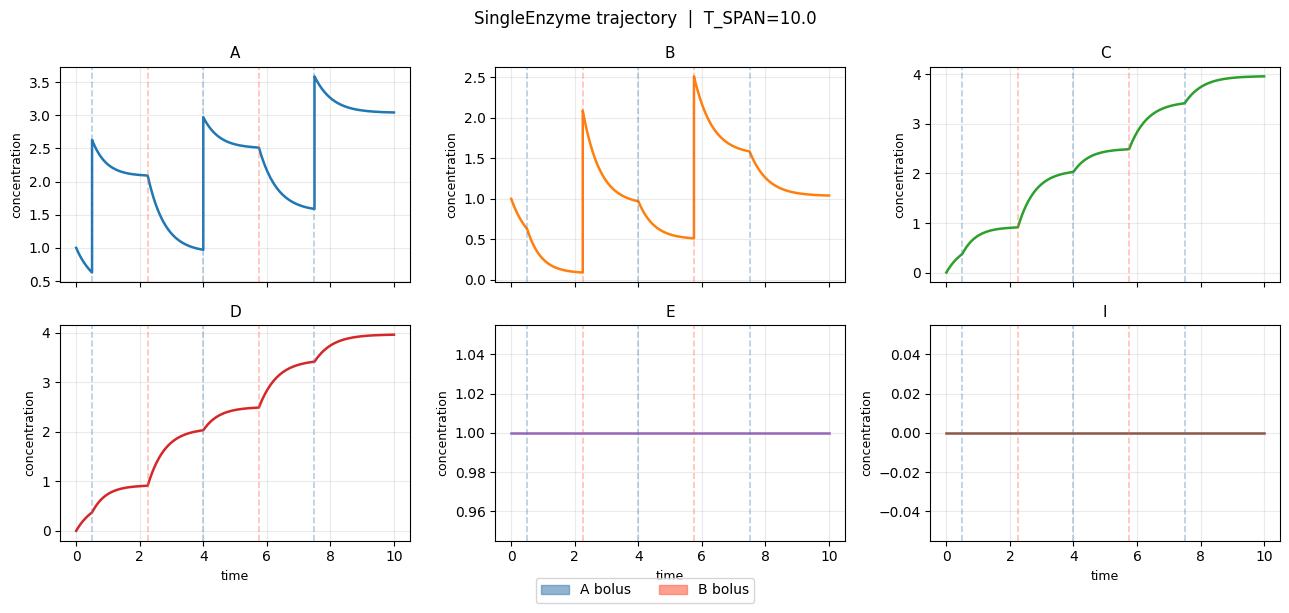

In [6]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
bolus_colors = {"A": "steelblue", "B": "tomato"}

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
axes_flat = axes.flatten()

for i, (ax, name) in enumerate(zip(axes_flat, state_names)):
    ax.plot(t_sol, x_sol[:, i], color=colors[i], linewidth=1.8)
    for t_b, ch, _ in events:
        ax.axvline(t_b, color=bolus_colors.get(ch, "grey"), alpha=0.4, linewidth=1.2, linestyle="--")
    ax.set_title(name, fontsize=11)
    ax.set_ylabel("concentration", fontsize=9)
    ax.grid(True, alpha=0.25)

for ax in axes[1]:
    ax.set_xlabel("time", fontsize=9)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=bolus_colors["A"], alpha=0.6, label="A bolus"),
    mpatches.Patch(color=bolus_colors["B"], alpha=0.6, label="B bolus"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"SingleEnzyme trajectory  |  T_SPAN={T_SPAN}", fontsize=12)
fig.tight_layout()
plt.show()

In [7]:
# ── Paste-able summary — copy this output and share it for evaluation ──────
from scipy.interpolate import interp1d

t_snap = np.linspace(0.0, T_SPAN, 21)  # 20 evenly spaced snapshots
x_snap = interp1d(t_sol, x_sol, axis=0)(t_snap)
bolus_interval = T_SPAN / 20 * 0.6

header = f"{'t':>6s}  " + "  ".join(f"{n:>7s}" for n in state_names)
print(header)
print("-" * len(header))
for t, row in zip(t_snap, x_snap):
    tag = ""
    for t_b, ch, _ in events:
        if abs(t - t_b) < bolus_interval:
            tag = f"  <- {ch} bolus"
    print(f"{t:6.2f}  " + "  ".join(f"{v:7.4f}" for v in row) + tag)

print()
print("Range (min -> max over full trajectory):")
for i, n in enumerate(state_names):
    print(f"  {n}: {x_sol[:, i].min():.4f} -> {x_sol[:, i].max():.4f}")

     t        A        B        C        D        E        I
------------------------------------------------------------
  0.00   1.0000   1.0000   0.0000   0.0000   1.0000   0.0000
  0.50   0.6280   0.6280   0.3720   0.3720   1.0000   0.0000  <- A bolus
  1.00   2.2571   0.2571   0.7429   0.7429   1.0000   0.0000
  1.50   2.1367   0.1367   0.8633   0.8633   1.0000   0.0000
  2.00   2.0986   0.0986   0.9014   0.9014   1.0000   0.0000  <- B bolus
  2.50   1.6618   1.6618   1.3382   1.3382   1.0000   0.0000  <- B bolus
  3.00   1.2153   1.2153   1.7847   1.7847   1.0000   0.0000
  3.50   1.0387   1.0387   1.9613   1.9613   1.0000   0.0000
  4.00   0.9703   0.9703   2.0297   2.0297   1.0000   0.0000  <- A bolus
  4.50   2.6709   0.6709   2.3291   2.3291   1.0000   0.0000
  5.00   2.5610   0.5610   2.4390   2.4390   1.0000   0.0000
  5.50   2.5217   0.5217   2.4783   2.4783   1.0000   0.0000  <- B bolus
  6.00   2.1703   2.1703   2.8297   2.8297   1.0000   0.0000  <- B bolus
  6.50   1.80